<a href="https://colab.research.google.com/github/balajiduddukuri/Langchain_practice/blob/Ultimate-Content-Repurposer/langraph_apr_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q openai langchain chromadb faiss-cpu pypdf tiktoken docarray

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71

In [ ]:
from google.colab import userdata

OPENAI_API_KEY = userdata.get("api_key")

print("Key loaded successfully")

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o",
    api_key=OPENAI_API_KEY
)

In [ ]:
#NODE

In [ ]:
#EDGE

In [ ]:
#STEP

# LangGrapgh
# AI Agents
# Multi-step wrkflows
# RAG pipelines
# Autonomous Systems

In [ ]:
!pip install -q langgraph langchain langchain-openai

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI

In [ ]:
class MyState(TypedDict):
  topic: str
  explanation: str
  summary: str
  quiz: str

In [ ]:
llm = ChatOpenAI(model = "gpt-4o-mini",api_key=OPENAI_API_KEY, temperature = 0.7)

In [ ]:
#NODE1:explain

def explain_node(state: MyState):
  response = llm.invoke(f"Explain {state["topic"]} in simple terms")
  return {
      "explanation": response.content
  }

In [ ]:
#Node2:summarize
def summarize_node(state: MyState):
  response = llm.invoke(f"Summarize this in 2 lines:\n{state["explanation"]}")
  return {
      "summary": response.content
  }


In [ ]:
#Node3:Quiz
def quiz_node(state: MyState):
  response = llm.invoke(f"Quiz me on this with 2 questions:\n{state["explanation"]}")
  return  {
      "quiz": response.content
  }

In [ ]:
graph = StateGraph(MyState)

graph.add_node("explain", explain_node)
graph.add_node("summarize", summarize_node)
graph.add_node("quiz", quiz_node)

graph.set_entry_point("explain")
graph.add_edge("explain", "summarize")
graph.add_edge("summarize", "quiz")
graph.add_edge("quiz", END)

In [ ]:
app = graph.compile()

In [ ]:
result = app.invoke({
    "topic": "Transformers"
})

print("\nExplanation:\n", result["explanation"])
print("\nSummary:\n", result["summary"])
print("\nquiz:\n", result["quiz"])


quiz:
 Here are two quiz questions based on the information you provided about transformers:

1. **What is the main feature of transformers that allows them to focus on different parts of the input text when making predictions?**  
   A) Parallel Processing  
   B) Attention Mechanism  
   C) Multi-layer Structure  
   D) Language Translation  

2. **How do transformers process text compared to older models?**  
   A) One word at a time  
   B) One sentence at a time  
   C) Simultaneously looking at all words in a sentence  
   D) Using only the first and last words of a sentence  

Feel free to answer these questions!


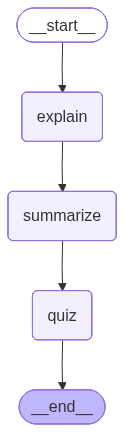

In [ ]:
from IPython.display import Image, display

# Assuming 'app' is already compiled from previous steps
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
#@haystack, @Autogen, @crewai

#conditional routing
#DEMO

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI

In [ ]:
import os
from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get("api_key")

In [ ]:
class MyState(TypedDict):
  topic: str
  difficulty: str
  output: str

In [ ]:
llm = ChatOpenAI(model = "gpt-4o-mini", temperature = 0.7)

In [ ]:
def classify_node(state: MyState):
  response = llm.invoke(
      f"Classify this topic as 'simple' or 'complex': {state['topic']}"
  )

  return {
      "difficulty": response.content.strip().lower()
  }

In [ ]:
def simple_node(state: MyState):
  response = llm.invoke(
      f"Explain {state['topic']} in 2 simple lines"
  )

  return {
      "output": response.content
  }

In [ ]:
def complex_node(state: MyState):
  response = llm.invoke(
      f"Explain {state['topic']} in detailed with example"
  )

  return {
      "output": response.content
  }

In [ ]:
def route(state: MyState):
  if "simple" in state['difficulty']:
    return "simple"
  else:
    return "complex"

In [ ]:
#Build graph

graph = StateGraph(MyState)
graph.add_node("classify", classify_node)
graph.add_node("simple", simple_node)
graph.add_node("complex", complex_node)


graph.set_entry_point("classify")

graph.add_conditional_edges(
    "classify",
    route,
    {
        "simple": "simple",
        "complex": "complex"
    }
)

graph.add_edge("simple", END)
graph.add_edge("complex", END)

In [ ]:
app = graph.compile()

In [ ]:
result = app.invoke({
    "topic": "Linear Regression"
})

print(result["output"])

Linear regression is a statistical method used to model the relationship between a dependent variable and one or more independent variables by fitting a linear equation to observed data. It aims to minimize the difference between predicted and actual values, allowing for predictions based on new input data.


In [ ]:
result = app.invoke({
    "topic": "math involved in the Tansformer architecture"
})

print(result["output"])

Certainly! The Transformer architecture, introduced in the paper "Attention is All You Need" by Vaswani et al. in 2017, revolutionized natural language processing by using a mechanism called self-attention. Below, I’ll break down the mathematical components of the Transformer architecture step-by-step, including the self-attention mechanism, which is central to its functioning.

### Key Components of the Transformer Architecture

1. **Input Representation**:
   - The input to the Transformer is a sequence of tokens (words or subwords) which are converted into vectors using embeddings. Each token is represented as a vector in a continuous space.

2. **Positional Encoding**:
   - Since the Transformer does not have any inherent understanding of the order of tokens (unlike RNNs), we add positional encodings to the input embeddings to retain information about the position of each token in the sequence. The positional encoding for position \( pos \) and dimension \( i \) is defined as:
    

Input Topic | [Node: Classify] | Decision (Simple/ Complex) | |-> [Node: Simple] |-> [Node: Complex] | END

AI Agents -> Decide whether to call tool or LLM
RAG Systems -> If a question needs context -> retrieve
We could route it to different workflows based on the user's intent

How is the Tool Calling possible in LangGraph?

In [ ]:
def decision_node(state: MyState):
  response = llm.invoke(
      f"Decide if this needs a calculator or LLM: {state['UserQuery']}",
      f"Repond only with 'tool' or 'LLM'. "
  )
  return {
      "decision": response.content.strip().lower()
  }

##PRACTICE PROGRAM

In [138]:
#decision_node.py — your code, fixed & extended

from langgraph.graph import StateGraph, END
from typing import TypedDict, Literal

# ── 1. Define State ──────────────────────────────────────────
class MyState(TypedDict):
    UserQuery: str
    decision:  str           # "tool" | "llm"
    output:    str

# ── 2. Decision Node ─────────────────────────────────────────
def decision_node(state: MyState):
    # Fix: llm.invoke() takes a single argument (list of messages)
    response = llm.invoke([
        {"role": "system", "content": "Decide if this needs a calculator or LLM. Respond ONLY with 'tool' or 'llm'."},
        {"role": "user",   "content": state["UserQuery"]},
    ])
    decision = response.content.strip().lower()
    if decision not in ("tool", "llm"):
        decision = "llm"  # safe fallback
    return {"decision": decision}

# ── 3. Branch Nodes ──────────────────────────────────────────
def tool_node(state: MyState):
    result = calculator.run(state["UserQuery"])
    return {"output": f"Calculator: {result}"}

def llm_node(state: MyState):
    response = llm.invoke([{"role": "user", "content": state["UserQuery"]}])
    return {"output": response.content}

# ── 4. Router Function (reads state, returns next node name) ──
def route_decision(state: MyState) -> Literal["tool", "llm"]:
    return state["decision"]   # LangGraph sends flow here

# ── 5. Build Graph ────────────────────────────────────────────
graph = StateGraph(MyState)
graph.add_node("decide",   decision_node)
graph.add_node("tool",     tool_node)
graph.add_node("llm",      llm_node)

graph.set_entry_point("decide")

# Conditional edge: run route_decision() after "decide"
graph.add_conditional_edges(
    "decide",
    route_decision,
    {"tool": "tool", "llm": "llm"}   # returned value → next node
)
graph.add_edge("tool", END)
graph.add_edge("llm",  END)

app = graph.compile()

In [139]:
#bind_tools.py — idiomatic production pattern
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict
from langchain_openai import ChatOpenAI

# ── 1. Define tools with @tool decorator ─────────────────────
@tool
def calculator(expression: str) -> str:
    """Evaluate a mathematical expression."""
    return str(eval(expression))   # use numexpr in production

@tool
def weather_lookup(city: str) -> str:
    """Get current weather for a city."""
    return f"Weather in {city}: 28°C, sunny"   # stub

tools = [calculator, weather_lookup]

# ── 2. Bind tools to LLM ─────────────────────────────────────
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)   # LLM knows which tools exist

# ── 3. State ─────────────────────────────────────────────────
class State(TypedDict):
    messages: Annotated[list, add_messages]  # auto-appends, no overwrite

# ── 4. Nodes ─────────────────────────────────────────────────
def agent_node(state: State):
    # LLM decides to call a tool or reply — returns AIMessage
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

tool_node = ToolNode(tools)   # prebuilt: auto-executes any tool call in last message

# ── 5. Graph with loop ───────────────────────────────────────
graph = StateGraph(State)
graph.add_node("agent", agent_node)
graph.add_node("tools", tool_node)

graph.set_entry_point("agent")

# tools_condition: routes to "tools" if AIMessage has tool_calls, else END
graph.add_conditional_edges("agent", tools_condition)
graph.add_edge("tools", "agent")  # loop back so LLM sees tool result

app = graph.compile()

# ── 6. Invoke ────────────────────────────────────────────────
result = app.invoke({"messages": [{"role": "user", "content": "What is 42 * 17?"}]})
print(result["messages"][-1].content)  # "The result is 714"

The result of \( 42 \times 17 \) is 714.


In [140]:
#rag_routing.py — conditional RAG retrieval
from langgraph.graph import StateGraph, END
from typing import TypedDict, Literal, Optional

class RAGState(TypedDict):
    question:  str
    context:   Optional[str]
    answer:    str
    needs_rag: bool

# ── Router: does this question need external context? ─────────
def classify_question(state: RAGState):
    response = llm.invoke([
        {"role": "system", "content": (
            "Does the question need product docs to answer? "
            "Reply ONLY with 'rag' or 'direct'."
        )},
        {"role": "user", "content": state["question"]},
    ])
    needs = response.content.strip().lower() == "rag"
    return {"needs_rag": needs}

def route_rag(state: RAGState) -> Literal["retrieve", "answer_direct"]:
    return "retrieve" if state["needs_rag"] else "answer_direct"

# ── Retrieval Node ────────────────────────────────────────────
def retrieve(state: RAGState):
    docs = vectorstore.similarity_search(state["question"], k=4)
    context = "\n\n".join(d.page_content for d in docs)
    return {"context": context}

# ── Answer Nodes ─────────────────────────────────────────────
def answer_with_context(state: RAGState):
    response = llm.invoke([
        {"role": "system", "content": "Answer using the context below."},
        {"role": "user", "content": f"Context:\n{state['context']}\n\nQ: {state['question']}"},
    ])
    return {"answer": response.content}

def answer_direct(state: RAGState):
    response = llm.invoke([{"role": "user", "content": state["question"]}])
    return {"answer": response.content}

# ── Graph ─────────────────────────────────────────────────────
graph = StateGraph(RAGState)
graph.add_node("classify",      classify_question)
graph.add_node("retrieve",      retrieve)
graph.add_node("answer_rag",    answer_with_context)
graph.add_node("answer_direct", answer_direct)

graph.set_entry_point("classify")
graph.add_conditional_edges("classify", route_rag, {
    "retrieve":      "retrieve",
    "answer_direct": "answer_direct",
})
graph.add_edge("retrieve", "answer_rag")
graph.add_edge("answer_rag",    END)
graph.add_edge("answer_direct", END)

rag_app = graph.compile()

In [141]:
#full_agent.py — multi-tool agent with loop & memory
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from typing import Annotated, TypedDict

# ── Tools ────────────────────────────────────────────────────
@tool
def search_web(query: str) -> str:
    """Search the web for current information."""
    return tavily_client.search(query)

@tool
def run_python(code: str) -> str:
    """Execute Python code and return output."""
    return python_repl.run(code)

@tool
def calculator(expr: str) -> str:
    """Evaluate a math expression."""
    import numexpr
    return str(numexpr.evaluate(expr).item())

tools = [search_web, run_python, calculator]
llm   = ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tools = llm.bind_tools(tools)

# ── State (messages reducer merges lists automatically) ───────
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

# ── Nodes ─────────────────────────────────────────────────────
def call_model(state: AgentState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# ── Graph (ReAct loop: agent ↔ tools) ─────────────────────────
graph = StateGraph(AgentState)
graph.add_node("agent", call_model)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "agent")
graph.add_conditional_edges(
    "agent",
    tools_condition,   # built-in: checks for tool_calls in AIMessage
    {"tools": "tools", END: END}
)
graph.add_edge("tools", "agent")   # loop: results go back to agent

# ── Compile with memory (conversation history per thread) ─────
memory = MemorySaver()
app = graph.compile(checkpointer=memory)

# ── Streaming invocation ──────────────────────────────────────
config = {"configurable": {"thread_id": "balu-session-1"}}
for event in app.stream(
    {"messages": [{"role": "user", "content": "What's 2^32 and who invented the transistor?"}]},
    config=config, stream_mode="values"
):
    last = event["messages"][-1]
    last.pretty_print()

================================ Human Message =================================

What's 2^32 and who invented the transistor?
================================== Ai Message ==================================
Tool Calls:
  calculator (call_ZhUAZcXGQHcFSdZhyY46pPBs)
 Call ID: call_ZhUAZcXGQHcFSdZhyY46pPBs
  Args:
    expr: 2^32
  search_web (call_mnUo6JJ4Se4BeUnqDpZSFi8b)
 Call ID: call_mnUo6JJ4Se4BeUnqDpZSFi8b
  Args:
    query: who invented the transistor


NameError: name 'tavily_client' is not defined